
Statistical comparisons (svs021) — median_intensity
  Non-parametric tests; Bonferroni correction: 3 pairwise comparison(s)
  Kruskal-Wallis: H=5.514, p=0.0635
  wt vs ∆pqsL: U=9.0, p=0.1000, p_bonf=0.3000  ns
  wt vs ∆rhlA ∆pqsL: U=9.0, p=0.1000, p_bonf=0.3000  ns
  ∆pqsL vs ∆rhlA ∆pqsL: U=5.0, p=1.0000, p_bonf=1.0000  ns

Statistical comparisons (svs002) — median_intensity
  Non-parametric tests; Bonferroni correction: 3 pairwise comparison(s)
  Kruskal-Wallis: H=5.956, p=0.0509
  wt vs ∆rhlA: U=9.0, p=0.1000, p_bonf=0.3000  ns
  wt vs ∆rhlA ∆pqsL: U=9.0, p=0.1000, p_bonf=0.3000  ns
  ∆rhlA vs ∆rhlA ∆pqsL: U=7.0, p=0.4000, p_bonf=1.0000  ns


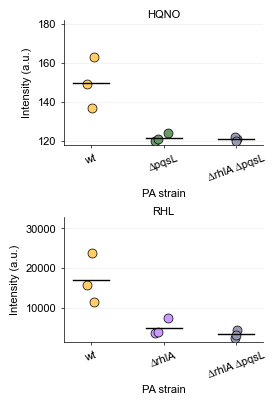

In [16]:

# =============================================================================
# IMPORTS
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# =============================================================================
# CONFIGURATION
# =============================================================================

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

PALETTE_HQNO = {
    'wt': '#ffcc66',
    '∆pqsL': '#669966',
    '∆rhlA ∆pqsL': '#9999B3',
}
PALETTE_RHL = {
    'wt': '#ffcc66',
    '∆rhlA': '#cc99ff',
    '∆rhlA ∆pqsL': '#9999B3',
}
ORDER = ['wt', '∆pqsL', '∆rhlA', '∆rhlA ∆pqsL']
CLASS_RANK = {c: i for i, c in enumerate(ORDER)}

# =============================================================================
# LOAD DATA
# =============================================================================

fcs_dir = '../analysis_code'
all_cells_df = pd.read_csv(f'{fcs_dir}/facs.csv')

rep_df = (
    all_cells_df
    .groupby(['strain', 'replicate', 'metric'], as_index=False)['intensity']
    .median()
    .rename(columns={'intensity': 'median_intensity'})
)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def classify_partner(partner: str) -> str:
    partner = str(partner).lower()
    if partner in {'svp005', 'svp053'}:
        return 'wt'
    if partner in {'svp043', 'svp054'}:
        return '∆pqsL'
    if partner == 'svp023':
        return '∆rhlA'
    if partner in {'svp029', 'svp069'}:
        return '∆rhlA ∆pqsL'
    return 'other'


def filter_and_classify(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    out = df[df['strain'].str.startswith(prefix + '-', na=False)].copy()
    out = out[~out['strain'].str.split('-').str[1].str.startswith('svs', na=False)].copy()
    out['partner'] = out['strain'].str.split('-').str[1]
    out['class'] = out['partner'].map(classify_partner)
    out = out[out['class'].isin(ORDER)].copy()
    out['class_rank'] = out['class'].map(CLASS_RANK)
    out = out.sort_values(['class_rank', 'strain', 'replicate']).reset_index(drop=True)
    return out

# =============================================================================
# STATISTICS HELPERS
# Non-parametric: Mann-Whitney U (pairwise) + Kruskal-Wallis (overall)
# =============================================================================

def _sig_symbol(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return None


def _bonferroni(p_val, n_comparisons):
    return min(p_val * n_comparisons, 1.0)


def _valid_pairs(df, class_order):
    present = set(df['class'].unique())
    active = [c for c in class_order if c in present]
    return [(active[i], active[j])
            for i in range(len(active))
            for j in range(i + 1, len(active))]


def print_class_stats(df, y_col, class_order, label=''):
    pairs = _valid_pairs(df, class_order)
    n_comp = len(pairs)

    print(f"\n{'='*70}")
    print(f"Statistical comparisons ({label}) — {y_col}")
    print(f"  Non-parametric tests; Bonferroni correction: {n_comp} pairwise comparison(s)")
    print(f"{'='*70}")

    present = [c for c in class_order if c in set(df['class'].unique())]
    groups = [df[df['class'] == c][y_col].dropna().values for c in present]
    if len(groups) > 1 and all(len(g) > 1 for g in groups):
        h_stat, p_kruskal = stats.kruskal(*groups)
        print(f"  Kruskal-Wallis: H={h_stat:.3f}, p={p_kruskal:.4f}")

    for c1, c2 in pairs:
        g1 = df[df['class'] == c1][y_col].dropna()
        g2 = df[df['class'] == c2][y_col].dropna()
        if len(g1) < 2 or len(g2) < 2:
            continue
        u_stat, p_raw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        p_bonf = _bonferroni(p_raw, n_comp)
        sym = _sig_symbol(p_bonf) or 'ns'
        print(f"  {c1} vs {c2}: U={u_stat:.1f}, p={p_raw:.4f}, p_bonf={p_bonf:.4f}  {sym}")


def annotate_class_stats(ax, df, y_col, class_order):
    pairs = _valid_pairs(df, class_order)
    n_comp = len(pairs)

    data_max = df[y_col].quantile(0.95)
    data_min = df[y_col].quantile(0.05)
    step = (data_max - data_min) * 0.10

    whisker_tops = {}
    for c in class_order:
        vals = df[df['class'] == c][y_col].dropna()
        if len(vals):
            q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
            whisker_tops[c] = min(q3 + 1.5 * (q3 - q1), vals.max())
    base_y = max(whisker_tops.values()) if whisker_tops else data_max

    for k, (c1, c2) in enumerate(pairs):
        g1 = df[df['class'] == c1][y_col].dropna()
        g2 = df[df['class'] == c2][y_col].dropna()
        if len(g1) < 2 or len(g2) < 2:
            continue
        _, p_raw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        p_bonf = _bonferroni(p_raw, n_comp)
        sym = _sig_symbol(p_bonf)
        if sym is None:
            continue

        x1 = class_order.index(c1)
        x2 = class_order.index(c2)
        y_bar = base_y + step * (k + 1)

        ax.plot([x1, x1, x2, x2],
                [y_bar - step * 0.25, y_bar, y_bar, y_bar - step * 0.25],
                lw=0.5, color='black', clip_on=False)
        ax.text((x1 + x2) / 2, y_bar + step * 0.05, sym,
                ha='center', va='bottom', fontsize=6, clip_on=False)

    current_top = ax.get_ylim()[1]
    needed_top = base_y + step * (len(pairs) + 2)
    ax.set_ylim(top=max(current_top, needed_top))

# =============================================================================
# PLOT HELPERS
# =============================================================================

def _style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.tick_params(axis='both', which='major', width=0.5, length=2, labelsize=8)
    ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)


def plot_group_on_ax(ax, prefix: str, metric: str, ylabel: str, title: str):
    """Strip plot: jittered individual replicates with a horizontal mean line."""
    plot_df = filter_and_classify(rep_df[rep_df['metric'] == metric], prefix)

    if plot_df.empty:
        ax.set_visible(False)
        print(f'No data to plot for {prefix}.')
        return

    palette = PALETTE_RHL if prefix == 'svs002' else PALETTE_HQNO
    class_order = [c for c in ORDER if c in plot_df['class'].values]
    rng = np.random.default_rng(42)

    for i, c in enumerate(class_order):
        ys = plot_df.loc[plot_df['class'] == c, 'median_intensity'].values
        color = palette.get(c, '#999999')
        jitter = rng.normal(0, 0.06, size=len(ys))
        ax.scatter(np.full(len(ys), i) + jitter, ys, s=42,
                   color=color, edgecolor='black', linewidth=0.5, zorder=3)
        mean_val = np.mean(ys)
        ax.plot([i - 0.25, i + 0.25], [mean_val, mean_val],
                color='black', linewidth=1.0, zorder=4)

    ax.set_xticks(range(len(class_order)))
    ax.set_xticklabels(class_order)
    annotate_class_stats(ax, plot_df, 'median_intensity', class_order)
    print_class_stats(plot_df, 'median_intensity', class_order, label=prefix)

    all_vals = plot_df['median_intensity'].dropna()
    y_min, y_max = all_vals.min(), all_vals.max()
    margin = (y_max - y_min) * 0.05
    ax.set_ylim(y_min - margin, ax.get_ylim()[1])
    ax.margins(y=0.1)

    ax.set_title(title, fontsize=8, pad=2)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xlabel('PA strain', fontsize=8)
    ax.tick_params(axis='x', labelrotation=20)
    _style_ax(ax)

# =============================================================================
# MAIN
# =============================================================================

fig, axs = plt.subplots(2, 2,
                        figsize=(2 * 6 / 2.54, 2 * 5 / 2.54),
                        constrained_layout=True)

plot_group_on_ax(axs[0, 0], prefix='svs021', metric='median_gfp',
                 ylabel='Intensity (a.u.)', title='HQNO')
plot_group_on_ax(axs[1, 0], prefix='svs002', metric='median_mcherry',
                 ylabel='Intensity (a.u.)', title='RHL')

axs[0, 1].set_visible(False)
axs[1, 1].set_visible(False)

plt.savefig('S13_facs.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()
